Источники данных:
⦁	
order.csv - информация о заявках на кредит (id заявки, дата создания заявки, дата выдачи кредита, дата закрытия, сумма кредита)
⦁	
payments.csv - фактические платежи клиентов (id заявки, дата оплаты, сумма оплаты)
⦁	
plan.csv - плановые платежи (id заявки, дата плановой оплаты, накопительная сумма)

Цель анализа: проанализировать характер поведения клиентов с точки зрения просрочки (какая динамика просрочки, наблюдается ли рост или снижение).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
orders = pd.read_csv("orders.csv")
payments = pd.read_csv("payments.csv")
plan = pd.read_csv("plan.csv")

print("Orders:\n", orders.head())
print("\nPayments:\n", payments.head())
print("\nPlan:\n", plan.head())

Orders:
     order_id               created_at                   put_at  \
0  400001732  2022-06-02 00:00:23.997  2022-06-02 20:18:00.180   
1  400005838  2022-06-02 00:10:22.997  2022-06-02 15:41:33.267   
2  400007915  2022-06-02 00:18:04.000  2022-06-05 19:17:38.547   
3  400008952  2022-06-02 00:22:07.000  2022-06-03 14:25:18.033   
4  400009027  2022-06-02 00:25:39.000  2022-06-02 00:40:40.320   

                 closed_at  issued_sum  
0  2022-10-17 11:52:22.190     13600.0  
1  2022-06-02 17:38:43.917     20000.0  
2  2022-06-21 21:55:51.877      5820.0  
3  2022-07-12 10:47:46.307      9000.0  
4  2022-06-22 14:15:07.423      5000.0  

Payments:
     order_id                  paid_at  paid_sum
0  400013633  2022-06-02 00:48:13.800    2500.0
1  400018480  2022-06-02 01:52:05.707    1070.0
2  400032001  2022-06-02 04:55:40.307    4200.0
3  400033195  2022-06-02 05:44:23.480    2850.0
4  400039407  2022-06-02 06:53:54.503   10100.0

Plan:
     order_id     plan_at  plan_sum_total

In [3]:
# Преобразование дат в datetime
date_columns = ["created_at", "put_at", "closed_at"]
orders[date_columns] = orders[date_columns].apply(pd.to_datetime, errors="coerce")
payments["paid_at"] = pd.to_datetime(payments["paid_at"], errors="coerce")
plan["plan_at"] = pd.to_datetime(plan["plan_at"], errors="coerce")

print("\nOrders types:\n", orders.dtypes)
print("\nPayments types:\n", payments.dtypes)
print("\nPlan types:\n", plan.dtypes)


Orders types:
 order_id               int64
created_at    datetime64[ns]
put_at        datetime64[ns]
closed_at     datetime64[ns]
issued_sum           float64
dtype: object

Payments types:
 order_id             int64
paid_at     datetime64[ns]
paid_sum           float64
dtype: object

Plan types:
 order_id                   int64
plan_at           datetime64[ns]
plan_sum_total           float64
dtype: object


In [4]:
# Сортируем данные для корректного расчета
plan = plan.sort_values(by=["order_id", "plan_at"])

# Вычисляем разовую сумму платежа
# diff() - метод, который в данном случае сделает из plan_sum_total разовые платежи, а не накопительную сумму
plan["plan_payment"] = plan.groupby("order_id")["plan_sum_total"].diff().fillna(plan["plan_sum_total"])
print("\nPlan после исправления накопительных платежей:\n", plan.head(10))


Plan после исправления накопительных платежей:
     order_id    plan_at  plan_sum_total  plan_payment
0  400001732 2022-06-02          5600.0        5600.0
1  400001732 2022-07-02          9450.0        3850.0
2  400001732 2022-08-01         12170.0        2720.0
3  400001732 2022-08-31         14890.0        2720.0
4  400001732 2022-09-30         17610.0        2720.0
5  400001732 2022-10-30         20330.0        2720.0
6  400001732 2022-11-29         23050.0        2720.0
7  400005838 2022-06-17         23000.0       23000.0
8  400007915 2022-06-05          1820.0        1820.0
9  400007915 2022-06-20          2730.0         910.0


In [5]:
# Считаем сумму всех фактических платежей по каждому order_id
total_paid = payments.groupby("order_id", as_index=False)["paid_sum"].sum()

# LEFT JOIN - используется для удобного соединения. К примеру, в plan.csv по одной заявке несколько записей, а в orders.csv лишь одна. Поэтому используем LEFT/RIGHT JOIN.
# Добавляем сумму кредита и дату закрытия
total_paid = total_paid.merge(orders[["order_id", "issued_sum", "closed_at"]], on="order_id", how="left")

# Фильтруем только те кредиты, которые полностью погашены
fully_paid_orders = total_paid.query("paid_sum >= issued_sum")[["order_id", "closed_at"]]

# Объединяем с плановыми платежами, чтобы исключить ненужные платежи
plan = plan.merge(fully_paid_orders, on="order_id", how="left")

# Оставляем только те строки, где либо кредит не закрыт, либо плановая дата раньше закрытия
plan = plan.query("closed_at.isna() or plan_at <= closed_at").drop(columns=["closed_at"])
print("\nPlan после удаления лишних платежей:\n", plan.head(10))


Plan после удаления лишних платежей:
      order_id    plan_at  plan_sum_total  plan_payment
0   400001732 2022-06-02         5600.00       5600.00
1   400001732 2022-07-02         9450.00       3850.00
2   400001732 2022-08-01        12170.00       2720.00
3   400001732 2022-08-31        14890.00       2720.00
4   400001732 2022-09-30        17610.00       2720.00
8   400007915 2022-06-05         1820.00       1820.00
9   400007915 2022-06-20         2730.00        910.00
21  400008952 2022-06-18        12628.36      12628.36
22  400009027 2022-06-17         6013.70       6013.70
23  400010534 2022-06-02         4600.00       4600.00


In [6]:
# Объединяем plan и payments по order_id
merged_data = plan.merge(payments, on="order_id", how="left")

# Добавляем данные о кредите
merged_data = merged_data.merge(orders[["order_id", "issued_sum", "put_at", "closed_at"]], on="order_id", how="left")
print("\nОбъединенные данные:\n", merged_data.head(10))




Объединенные данные:
     order_id    plan_at  plan_sum_total  plan_payment                 paid_at  \
0  400001732 2022-06-02          5600.0        5600.0 2022-06-02 20:20:16.790   
1  400001732 2022-06-02          5600.0        5600.0 2022-06-16 16:05:26.007   
2  400001732 2022-06-02          5600.0        5600.0 2022-07-15 12:32:34.087   
3  400001732 2022-06-02          5600.0        5600.0 2022-08-16 12:38:01.237   
4  400001732 2022-06-02          5600.0        5600.0 2022-09-15 12:14:48.867   
5  400001732 2022-06-02          5600.0        5600.0 2022-09-27 16:04:50.630   
6  400001732 2022-06-02          5600.0        5600.0 2022-10-17 11:52:22.190   
7  400001732 2022-07-02          9450.0        3850.0 2022-06-02 20:20:16.790   
8  400001732 2022-07-02          9450.0        3850.0 2022-06-16 16:05:26.007   
9  400001732 2022-07-02          9450.0        3850.0 2022-07-15 12:32:34.087   

   paid_sum  issued_sum                  put_at               closed_at  
0    5600.0

In [7]:
# Определяем просрочку по дате и сумме
merged_data["is_overdue"] = (merged_data["paid_at"] > merged_data["plan_at"]) | \
                            (merged_data["paid_sum"] < merged_data["plan_payment"])
print("\nПросроченные платежи:\n", merged_data[["order_id", "plan_at", "paid_at", "plan_payment", "paid_sum", "is_overdue"]].head(10))

# Подсчитываем процент просрочек
total_overdue_percentage = merged_data["is_overdue"].mean() * 100
print(f"\nОбщий процент просрочек: {total_overdue_percentage:.2f}%")


Просроченные платежи:
     order_id    plan_at                 paid_at  plan_payment  paid_sum  \
0  400001732 2022-06-02 2022-06-02 20:20:16.790        5600.0    5600.0   
1  400001732 2022-06-02 2022-06-16 16:05:26.007        5600.0    3850.0   
2  400001732 2022-06-02 2022-07-15 12:32:34.087        5600.0    2720.0   
3  400001732 2022-06-02 2022-08-16 12:38:01.237        5600.0    2720.0   
4  400001732 2022-06-02 2022-09-15 12:14:48.867        5600.0    2720.0   
5  400001732 2022-06-02 2022-09-27 16:04:50.630        5600.0    2720.0   
6  400001732 2022-06-02 2022-10-17 11:52:22.190        5600.0    2720.0   
7  400001732 2022-07-02 2022-06-02 20:20:16.790        3850.0    5600.0   
8  400001732 2022-07-02 2022-06-16 16:05:26.007        3850.0    3850.0   
9  400001732 2022-07-02 2022-07-15 12:32:34.087        3850.0    2720.0   

   is_overdue  
0        True  
1        True  
2        True  
3        True  
4        True  
5        True  
6        True  
7       False  
8     

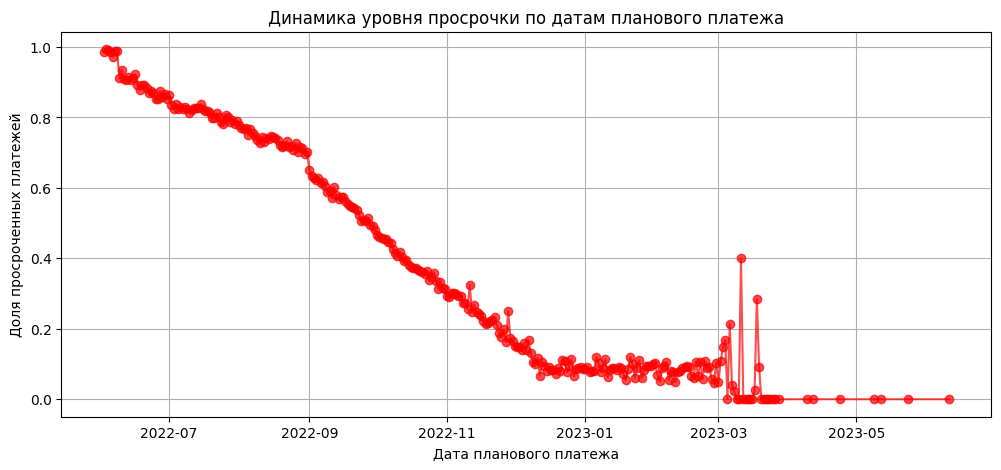

In [8]:
# Группируем данные по дате планового платежа и считаем долю просрочек
overdue_trend = merged_data.groupby("plan_at")["is_overdue"].mean()

plt.figure(figsize=(12, 5))
plt.plot(overdue_trend.index, overdue_trend.values, marker="o", linestyle="-", color="red", alpha=0.7)

plt.title("Динамика уровня просрочки по датам планового платежа")
plt.xlabel("Дата планового платежа")
plt.ylabel("Доля просроченных платежей")
plt.grid(True)
plt.show()

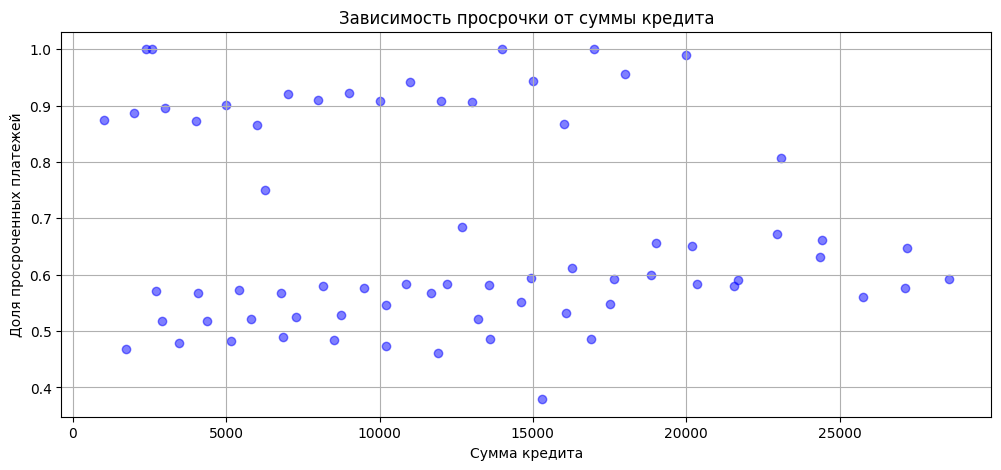

In [9]:
# Группируем по сумме кредита и считаем средний уровень просрочек
overdue_by_credit_sum = merged_data.groupby("issued_sum")["is_overdue"].mean()

# Строим график зависимости просрочки от суммы кредита
plt.figure(figsize=(12, 5))
plt.scatter(overdue_by_credit_sum.index, overdue_by_credit_sum.values, color="blue", alpha=0.5)
plt.title("Зависимость просрочки от суммы кредита")
plt.xlabel("Сумма кредита")
plt.ylabel("Доля просроченных платежей")
plt.grid(True)
plt.show()

In [10]:
# Группируем по сумме кредита и считаем долю просроченных платежей
overdue_by_credit_sum = merged_data.groupby("issued_sum")["is_overdue"].mean().reset_index()

# Сортируем по убыванию просрочек
overdue_by_credit_sum = overdue_by_credit_sum.sort_values(by="is_overdue", ascending=False)

# Выводим топ-10 сумм кредитов с наибольшими просрочками
print(overdue_by_credit_sum.head(10))

    issued_sum  is_overdue
4       2570.0    1.000000
3       2390.0    1.000000
42     14000.0    1.000000
51     17000.0    1.000000
57     20000.0    0.990148
54     18000.0    0.955556
45     15000.0    0.942857
32     11000.0    0.941423
26      9000.0    0.922727
20      7000.0    0.920188


In [11]:
# Выбираем кредиты, у которых уровень просрочки больше 80%
high_overdue_loans = overdue_by_credit_sum[overdue_by_credit_sum["is_overdue"] > 0.8]

# Считаем среднюю сумму кредита среди таких заявок
average_high_overdue_credit = high_overdue_loans["issued_sum"].mean()
print(f"Средняя сумма кредита среди заявок с высокой просрочкой: {average_high_overdue_credit:.2f}")

Средняя сумма кредита среди заявок с высокой просрочкой: 9956.82



Процент просроченных платежей по месяцам: 
plan_month
2022-06    89.645232
2022-07    81.303824
2022-08    73.402413
2022-09    56.987911
2022-10    39.087999
2022-11    24.714649
2022-12    10.651065
2023-01     8.775649
2023-02     8.007862
2023-03     9.256662
2023-04     0.000000
2023-05     0.000000
2023-06     0.000000
Freq: M, Name: is_overdue, dtype: float64


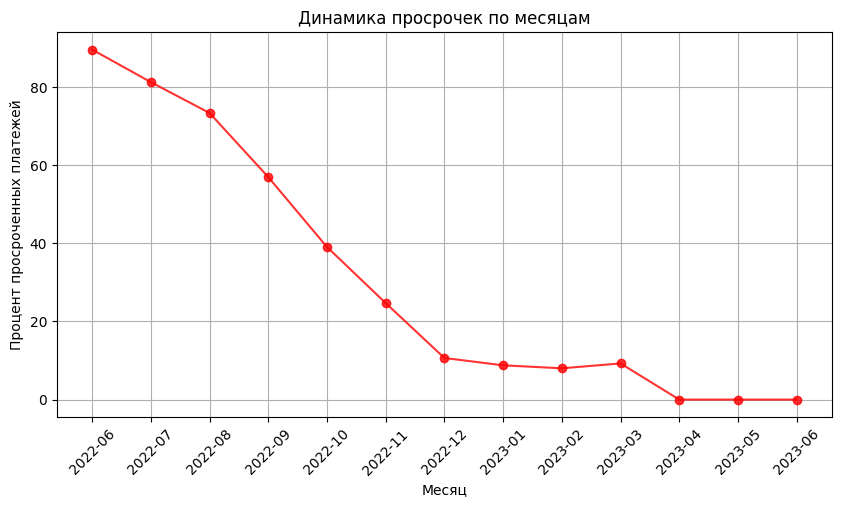

In [12]:
# Добавляем колонку с месяцем планового платежа
merged_data["plan_month"] = merged_data["plan_at"].dt.to_period("M")

# Группируем по месяцам и считаем долю просроченных платежей
overdue_by_month = merged_data.groupby("plan_month")["is_overdue"].mean() * 100
print(f'\nПроцент просроченных платежей по месяцам: \n{overdue_by_month}')

# Построение графика
plt.figure(figsize=(10, 5))
plt.plot(overdue_by_month.index.astype(str), overdue_by_month.values, marker="o", linestyle="-", color="red", alpha=0.8)

plt.title("Динамика просрочек по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Процент просроченных платежей")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Топ-5 месяцев по количеству выданных кредитов:
put_at
2022-08    19331
2022-07    19085
2022-06    15899
2022-09     1433
Freq: M, Name: count, dtype: int64


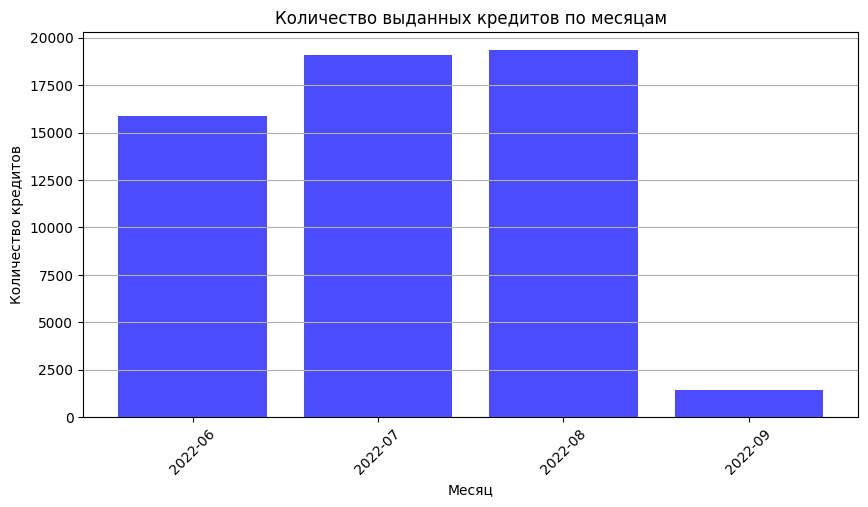

In [13]:
# Извлекаем месяц и считаем количество кредитов
credits_by_month = orders["put_at"].dt.to_period("M").value_counts().sort_index()

print("\nТоп-5 месяцев по количеству выданных кредитов:")
print(credits_by_month.sort_values(ascending=False).head())

plt.figure(figsize=(10, 5))
plt.bar(credits_by_month.index.astype(str), credits_by_month.values, color="blue", alpha=0.7)

plt.title("Количество выданных кредитов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество кредитов")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()



Общий анализ уровня просрочек:
⦁	Общий процент просроченных платежей: 55.01%
⦁	К маю 2023 года заметно значительное снижение уровня просрочек. Самый пик приходится на июль 2022 года.
Вывод: большинство клиентов не выполняет условия платежного графика, задерживают платежи или вносят не полную сумму.

Динамика просрочек по времени:
⦁	Пик просрочек приходится на весну-лето 2022 года.
⦁	К концу лета заметно снижение уровня просрочек.
⦁	К 2023 году видно снижение уровня просрочек. Весной 2023 года уровень просрочек близится к наименьшим показателям.
⦁	В середине марта заметен незначительный скачок уровня просрочек.


Влияние суммы кредита на просрочку.
⦁	Кредиты на сумму до 20.000 рублей чаще всего уходят в просрочку.
⦁	Кредиты среднего размера (от 25.000 рублей) имеют более низкий уровень просрочек. Основываясь на этом, можно сделать вывод о проблемах именно с микрозаймами. Можно предположить, что это связано с низкой платёжеспособностью заёмщиков в этом сегменте.
⦁	Пик просрочек приходится на суммы кредитов: 2570, 2390, 14000, 17000 рублей.


Активность клиентов относительно времени (по месяцам).
Наибольшее количество выданных кредитов приходится на лето 2022 года. Это может быть связано со снижением ключевой ставки летом 2022 года, а также с реакцией на экономическую ситуацию (введение санкций). Также играет роль сезонный фактор.
